# Only dark acid fast club plot

In [207]:
df = pd.read_csv('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/dt_lit_dist.csv')

In [208]:
df.keys()

Index(['First author', 'Year', 'Journal', 'Context', 'Host Type',
       'Host cell details', 'Mtb Strain details', 'Culture details',
       'Intrinsic/Extrinsic growth', 'Single-cell doubling time', 'Median (h)',
       'Q1 (h)', 'Q3 (h)', 'N', 'Min dt (h)', 'Max dt (h)', 'Notes', 'Notes.1',
       'Analysis notes', 'PMID', 'Raw data', 'Raw data notes'],
      dtype='object')

# Final draft

In [209]:
# Cell 1: imports, config, load
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm

# Style
sns.set_theme(style="white")
mpl.rcParams["font.family"] = "Helvetica"#"Nimbus Sans" 

# ---- CONFIG ----
csv_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/dt_lit_dist.csv'# 'for import into python-Table 1.csv' #"/Users/dayn/Documents/mtb growth rate dictionary/for import into python-Table 1.csv"
xmin, xmax = 1, 120        # plotting range (hours)

# Preferred palette (expanded_piyg)
palette = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

# Load
df = pd.read_csv(csv_path)
df.drop(index=3, inplace=True)
# Ensure numeric
numcols = ["Median (h)", "Q1 (h)", "Q3 (h)", "N", "Min dt (h)", "Max dt (h)"]
for c in numcols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Compose ID label once (you can tweak format here)
df["ID"] = (
    df["First author"].fillna("").astype(str)
    + " " + df["Year"].fillna("").astype(str)
    + ", " + df["Journal"].fillna("").astype(str)
)

# Optional: keep only rows with quartiles + N present
df = df.dropna(subset=["Median (h)", "Q1 (h)", "Q3 (h)", "N"]).copy()

In [210]:
# cell 1.5 add our data
# our_df = pd.read_pickle('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl')

In [211]:
our_df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


In [212]:
df_mask = ((our_df['Strain'] == 'WT') &
          (our_df['Compound'] == 'CTRL') &
          (our_df['Concentration'] == 'EC0') &
          (our_df['mtb_origin'] == 'Growth')
           )

our_dts = our_df[df_mask].drop_duplicates('ID').explode('Doubling Times')['Doubling Times']

our_dts = our_dts[our_dts >0]

# median
median = our_dts.median()

# first quartile (25th percentile)
q1 = our_dts.quantile(0.25)

# third quartile (75th percentile)
q3 = our_dts.quantile(0.75)

N = len(our_df[df_mask].drop_duplicates('ID'))
print(f"Median: {median}, Q1: {q1}, Q3: {q3}, N: {N}")

Median: 24.75, Q1: 19.0, Q3: 33.0, N: 219


In [213]:
print(f"Median: {median}, Q1: {q1}, Q3: {q3}, N: {N}")

Median: 24.75, Q1: 19.0, Q3: 33.0, N: 219


In [214]:
new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'H37Rv',
    'Culture details': 'Intracellular',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': median,
    'Q1 (h)': q1,
    'Q3 (h)': q3,
    'N': N,  # sample size if you want
    'Min dt (h)': our_dts.min(),
    'Max dt (h)': our_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


In [215]:
# 1. Filter the dataframe
rd1_mask = (
    (our_df['Strain'] == 'RD1')
    & (our_df['Compound'] == 'CTRL')
    & (our_df['Concentration'] == 'EC0')
    & (our_df['mtb_origin'] == 'Growth')
)
# 2. Extract and clean doubling times
rd1_dts = (
    our_df[rd1_mask]
    .drop_duplicates('ID')                # ensure unique cells
    .explode('Doubling Times')['Doubling Times']  # flatten lists
)
rd1_dts = rd1_dts[rd1_dts > 0]             # remove invalid / non-positive

# 3. Compute stats
rd1_median = rd1_dts.median()
rd1_q1 = rd1_dts.quantile(0.25)
rd1_q3 = rd1_dts.quantile(0.75)
rd1_N = len(our_df[rd1_mask].drop_duplicates('ID'))

# 4. Print summary
print(f"RD1  →  Median: {rd1_median:.2f} h | Q1: {rd1_q1:.2f} h | Q3: {rd1_q3:.2f} h | N: {rd1_N}")


RD1  →  Median: 39.50 h | Q1: 20.75 h | Q3: 58.25 h | N: 83


In [216]:
new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'ΔRD1',
    'Culture details': 'Intracellular ΔRD1',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': rd1_median,
    'Q1 (h)': rd1_q1,
    'Q3 (h)': rd1_q3,
    'N': rd1_N,  # sample size if you want
    'Min dt (h)': rd1_dts.min(),
    'Max dt (h)': rd1_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


In [217]:
df

,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,NaN,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
3,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Extracellular,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Possibly extractable,"Growth rate (ln2), distribution shown in F5B","Mahamed 2017, eLife"
4,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
5,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Extracellular near dead alveolar macrophages,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
6,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,IFNγ treated,Extrinsic,No,...,49,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
7,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
8,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Extracellular,Extrinsic,Yes,...,21,NaN,NaN,"Reciprocal, Fig. 4B",Faster extracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
9,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,ESX1,Intracellular in ESX-1,Intrinsic,Yes,...,45,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular mutant replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"


In [218]:
# Cell 2: build Gaussian-based plot_df (no recompute needed later)
# Gaussian with mu = Median(h); sigma from IQR: sigma = (Q3 - Q1) / (2*z0.75)

zq = 0.67448975  # Phi^{-1}(0.75)
npoints = 300
xs = np.linspace(xmin, xmax, npoints)

def gaussian_plot_rows(df_in):
    rows = []
    for _, r in df_in.iterrows():
        med, q1, q3, N = r["Median (h)"], r["Q1 (h)"], r["Q3 (h)"], r["N"]
        mu = float(med)
        sigma = (float(q3) - float(q1)) / (2.0 * zq)
        if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(mu):
            continue

        pdf = np.exp(-0.5 * ((xs - mu) / sigma)**2) / (sigma * np.sqrt(2*np.pi))
        pdf = pdf / pdf.max() * np.sqrt(float(N))   # peak ∝ √N

        rows.append(pd.DataFrame({
            "x": xs,
            "y": pdf,
            "ID": r["ID"],
            "Culture details": r["Culture details"]
        }))
    if not rows:
        return pd.DataFrame(columns=["x","y","ID","Culture details"])
    return pd.concat(rows, ignore_index=True)

plot_df = gaussian_plot_rows(df)
plot_df.head()

,x,y,ID,Culture details
0,1.000000,0.045601,"Chung 2024, Nat Micro",Rich medium microfluidic device
1,1.397993,0.062975,"Chung 2024, Nat Micro",Rich medium microfluidic device
2,1.795987,0.086200,"Chung 2024, Nat Micro",Rich medium microfluidic device
3,2.193980,0.116947,"Chung 2024, Nat Micro",Rich medium microfluidic device
4,2.591973,0.157261,"Chung 2024, Nat Micro",Rich medium microfluidic device


In [219]:
# Cell 3: adaptive layout helpers (spacing only)
def compute_layout(plot_df, df_summary,
                   height_scale=1.0, gain=2.0,
                   substep_min=10.0, k_sub=0.9,
                   base_gap=6.0, k_gap=0.5):
    """
    Returns: ids_order, peaks, id_specs, y_center, base_for, colors
    All computed from plot_df; you can change the knobs without rebuilding plot_df.
    """
    # Tallest ridge per (ID, culture) in plot units
    peaks = (plot_df.groupby(["ID","Culture details"])["y"]
                   .max()
                   .mul(height_scale * gain)
                   .rename("ypeak")
                   .reset_index())

    ids_order = list(pd.unique(plot_df["ID"]))

    # Adaptive substep and half-height per ID
    id_specs, id_substep = {}, {}
    for idv in ids_order:
        cults = list(pd.unique(plot_df.loc[plot_df["ID"] == idv, "Culture details"]))
        ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
        sub_i = max(substep_min, k_sub * float(ypeak_max))
        half  = 0.5*((len(cults)-1)*sub_i) + 0.5*float(ypeak_max)
        id_specs[idv]  = {"cults": cults, "half": half, "ypeak_max": float(ypeak_max)}
        id_substep[idv] = sub_i

    # Place groups with adaptive gap
    y_center, current_y = {}, 0.0
    for i, idv in enumerate(ids_order):
        half = id_specs[idv]["half"]
        if i == 0:
            y_center[idv] = 0.0
        else:
            prev = ids_order[i-1]
            gap_i = max(base_gap, k_gap * max(id_specs[prev]["ypeak_max"], id_specs[idv]["ypeak_max"]))
            y_center[idv] = current_y - (id_specs[prev]["half"] + gap_i + half)
        current_y = y_center[idv]

    # Baselines for each (ID, culture) centered and equally spaced
    base_for = {}
    for idv in ids_order:
        cults = id_specs[idv]["cults"]
        sub_i = id_substep[idv]
        n_c   = len(cults)
        for j, cult in enumerate(cults):
            base_for[(idv, cult)] = y_center[idv] - (n_c - 1) * sub_i / 2.0 + j * sub_i

    # Colors for Culture details using PiYG colormap
    cult_levels = pd.unique(plot_df["Culture details"])
    n_cults     = len(cult_levels)
    
    # make a PiYG palette long enough (repeats if n_cults > base palette size)
    pal = sns.color_palette("rocket", n_colors=n_cults)
    
    # assign colors per culture detail
    colors = {c: pal[i % len(pal)] for i, c in enumerate(cult_levels)}
    return ids_order, peaks, id_specs, y_center, base_for, colors

## Adding antibiotics

In [220]:
# Cell 1: imports, config, load
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm

# Style
sns.set_theme(style="white")
mpl.rcParams["font.family"] = "Helvetica"#"Nimbus Sans" 

# ---- CONFIG ----
csv_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/dt_lit_dist.csv'# 'for import into python-Table 1.csv' #"/Users/dayn/Documents/mtb growth rate dictionary/for import into python-Table 1.csv"
xmin, xmax = 1, 120        # plotting range (hours)

# Preferred palette (expanded_piyg)
palette = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

# Load
df = pd.read_csv(csv_path)
df.drop(index=3, inplace=True)
# Ensure numeric
numcols = ["Median (h)", "Q1 (h)", "Q3 (h)", "N", "Min dt (h)", "Max dt (h)"]
for c in numcols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Compose ID label once (you can tweak format here)
df["ID"] = (
    df["First author"].fillna("").astype(str)
    + " " + df["Year"].fillna("").astype(str)
    + ", " + df["Journal"].fillna("").astype(str)
)

# Optional: keep only rows with quartiles + N present
df = df.dropna(subset=["Median (h)", "Q1 (h)", "Q3 (h)", "N"]).copy()

In [221]:
df_mask = ((our_df['Strain'] == 'WT') &
          (our_df['Compound'] == 'CTRL') &
          (our_df['Concentration'] == 'EC0') &
          (our_df['mtb_origin'] == 'Growth')
           )

our_dts = our_df[df_mask].drop_duplicates('ID').explode('Doubling Times')['Doubling Times']

our_dts = our_dts[our_dts >0]

# median
median = our_dts.median()

# first quartile (25th percentile)
q1 = our_dts.quantile(0.25)

# third quartile (75th percentile)
q3 = our_dts.quantile(0.75)

N = len(our_df[df_mask].drop_duplicates('ID'))
print(f"Median: {median}, Q1: {q1}, Q3: {q3}, N: {N}")

new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'H37Rv',
    'Culture details': 'Intracellular',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': median,
    'Q1 (h)': q1,
    'Q3 (h)': q3,
    'N': N,  # sample size if you want
    'Min dt (h)': our_dts.min(),
    'Max dt (h)': our_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


# 1. Filter the dataframe
rd1_mask = (
    (our_df['Strain'] == 'RD1')
    & (our_df['Compound'] == 'CTRL')
    & (our_df['Concentration'] == 'EC0')
    & (our_df['mtb_origin'] == 'Growth')
)
# 2. Extract and clean doubling times
rd1_dts = (
    our_df[rd1_mask]
    .drop_duplicates('ID')                # ensure unique cells
    .explode('Doubling Times')['Doubling Times']  # flatten lists
)
rd1_dts = rd1_dts[rd1_dts > 0]             # remove invalid / non-positive

# 3. Compute stats
rd1_median = rd1_dts.median()
rd1_q1 = rd1_dts.quantile(0.25)
rd1_q3 = rd1_dts.quantile(0.75)
rd1_N = len(our_df[rd1_mask].drop_duplicates('ID'))

# 4. Print summary
print(f"RD1  →  Median: {rd1_median:.2f} h | Q1: {rd1_q1:.2f} h | Q3: {rd1_q3:.2f} h | N: {rd1_N}")


new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'ΔRD1',
    'Culture details': 'Intracellular ΔRD1',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': rd1_median,
    'Q1 (h)': rd1_q1,
    'Q3 (h)': rd1_q3,
    'N': rd1_N,  # sample size if you want
    'Min dt (h)': rd1_dts.min(),
    'Max dt (h)': rd1_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


df

Median: 24.75, Q1: 19.0, Q3: 33.0, N: 219
RD1  →  Median: 39.50 h | Q1: 20.75 h | Q3: 58.25 h | N: 83


,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,NaN,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
3,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Extracellular,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Possibly extractable,"Growth rate (ln2), distribution shown in F5B","Mahamed 2017, eLife"
4,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
5,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Extracellular near dead alveolar macrophages,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
6,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,IFNγ treated,Extrinsic,No,...,49,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
7,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
8,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Extracellular,Extrinsic,Yes,...,21,NaN,NaN,"Reciprocal, Fig. 4B",Faster extracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
9,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,ESX1,Intracellular in ESX-1,Intrinsic,Yes,...,45,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular mutant replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"


In [222]:
# ------------------------------------------
# Helper to avoid repetition
# ------------------------------------------
def add_condition_row(df, our_df, strain, compound, conc, origin,
                      label, culture_label):
    """
    Filter our_df, compute stats, and append a new row to df.
    """
    mask = (
        (our_df['Strain'] == strain)
        & (our_df['Compound'] == compound)
        & (our_df['Concentration'] == conc)
        & (our_df['mtb_origin'] == origin)
    )

    dts = (
        our_df[mask]
        .drop_duplicates('ID')
        .explode('Doubling Times')['Doubling Times']
    )
    dts = dts[dts > 0]

    median = dts.median()
    q1 = dts.quantile(0.25)
    q3 = dts.quantile(0.75)
    N = len(our_df[mask].drop_duplicates('ID'))

    print(f"{label} → Median: {median:.2f} h | Q1: {q1:.2f} h | Q3: {q3:.2f} h | N: {N}")

    new_row = {
        'First author': 'Day, Pradel, Luk',
        'Year': 2025,
        'Journal': 'TBC',
        'Context': 'in cellulo',
        'Host Type': 'Human',
        'Host cell details': 'IPSDM',
        'Mtb Strain details': 'H37Rv',
        'Culture details': culture_label,
        'Intrinsic/Extrinsic growth': 'Intrinsic',
        'Single-cell doubling time': 'Yes',
        'Median (h)': median,
        'Q1 (h)': q1,
        'Q3 (h)': q3,
        'N': N,
        'Min dt (h)': dts.min(),
        'Max dt (h)': dts.max(),
        'Notes': '',
        'Notes.1': '',
        'Analysis notes': '',
        'PMID': '',
        'Raw data': '',
        'Raw data notes': '',
        'ID': f'Day, Pradel, Luk, 2025'
    }

    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


# ------------------------------------------
# Add WT–PZA, WT–INH, WT–RIF
# ------------------------------------------

df = add_condition_row(df, our_df,
                       strain='WT',
                       compound='PZA',
                       conc='EC99',
                       origin='Growth',
                       label='WT + PZA',
                       culture_label='Intracellular PZA treated')

df = add_condition_row(df, our_df,
                       strain='WT',
                       compound='INH',
                       conc='EC99',
                       origin='Growth',
                       label='WT + INH',
                       culture_label='Intracellular INH treated')

df = add_condition_row(df, our_df,
                       strain='WT',
                       compound='RIF',
                       conc='EC99',
                       origin='Growth',
                       label='WT + RIF',
                       culture_label='Intracellular RIF treated')


# Show updated table
df.tail(5)


WT + PZA → Median: 24.50 h | Q1: 14.50 h | Q3: 40.00 h | N: 24
WT + INH → Median: 19.50 h | Q1: 10.25 h | Q3: 44.25 h | N: 46
WT + RIF → Median: 9.50 h | Q1: 6.50 h | Q3: 25.50 h | N: 29


,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
11,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular,Intrinsic,Yes,...,219,4.0,68.0,,,,,,,"Day, Pradel, Luk, 2025"
12,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,ΔRD1,Intracellular ΔRD1,Intrinsic,Yes,...,83,7.0,68.0,,,,,,,"Day, Pradel, Luk, 2025"
13,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular PZA treated,Intrinsic,Yes,...,24,4.0,73.5,,,,,,,"Day, Pradel, Luk, 2025"
14,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular INH treated,Intrinsic,Yes,...,46,1.5,67.0,,,,,,,"Day, Pradel, Luk, 2025"
15,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular RIF treated,Intrinsic,Yes,...,29,3.0,48.0,,,,,,,"Day, Pradel, Luk, 2025"


In [223]:
# Cell 2: build Gaussian-based plot_df (no recompute needed later)
# Gaussian with mu = Median(h); sigma from IQR: sigma = (Q3 - Q1) / (2*z0.75)

zq = 0.67448975  # Phi^{-1}(0.75)
npoints = 300
xs = np.linspace(xmin, xmax, npoints)

def gaussian_plot_rows(df_in):
    rows = []
    for _, r in df_in.iterrows():
        med, q1, q3, N = r["Median (h)"], r["Q1 (h)"], r["Q3 (h)"], r["N"]
        mu = float(med)
        sigma = (float(q3) - float(q1)) / (2.0 * zq)
        if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(mu):
            continue

        pdf = np.exp(-0.5 * ((xs - mu) / sigma)**2) / (sigma * np.sqrt(2*np.pi))
        pdf = pdf / pdf.max() * np.sqrt(float(N))   # peak ∝ √N

        rows.append(pd.DataFrame({
            "x": xs,
            "y": pdf,
            "ID": r["ID"],
            "Culture details": r["Culture details"]
        }))
    if not rows:
        return pd.DataFrame(columns=["x","y","ID","Culture details"])
    return pd.concat(rows, ignore_index=True)

plot_df = gaussian_plot_rows(df)
plot_df.head()

,x,y,ID,Culture details
0,1.000000,0.045601,"Chung 2024, Nat Micro",Rich medium microfluidic device
1,1.397993,0.062975,"Chung 2024, Nat Micro",Rich medium microfluidic device
2,1.795987,0.086200,"Chung 2024, Nat Micro",Rich medium microfluidic device
3,2.193980,0.116947,"Chung 2024, Nat Micro",Rich medium microfluidic device
4,2.591973,0.157261,"Chung 2024, Nat Micro",Rich medium microfluidic device


In [224]:
# --- adaptive layout (unchanged) ---
def compute_layout(plot_df, df_summary,
                   height_scale=1.0, gain=2.0,
                   substep_min=10.0, k_sub=0.9,
                   base_gap=6.0, k_gap=0.5):
    """
    Returns: ids_order, peaks, id_specs, y_center, base_for, colors
    """
    peaks = (plot_df.groupby(["ID","Culture details"])["y"]
                   .max()
                   .mul(height_scale * gain)
                   .rename("ypeak")
                   .reset_index())

    ids_order = list(pd.unique(plot_df["ID"]))

    id_specs, id_substep = {}, {}
    for idv in ids_order:
        cults = list(pd.unique(plot_df.loc[plot_df["ID"] == idv, "Culture details"]))
        ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
        sub_i = max(substep_min, k_sub * float(ypeak_max))
        half  = 0.5*((len(cults)-1)*sub_i) + 0.5*float(ypeak_max)
        id_specs[idv]  = {"cults": cults, "half": half, "ypeak_max": float(ypeak_max)}
        id_substep[idv] = sub_i

    y_center, current_y = {}, 0.0
    for i, idv in enumerate(ids_order):
        half = id_specs[idv]["half"]
        if i == 0:
            y_center[idv] = 0.0
        else:
            prev = ids_order[i-1]
            gap_i = max(base_gap, k_gap * max(id_specs[prev]["ypeak_max"], id_specs[idv]["ypeak_max"]))
            y_center[idv] = current_y - (id_specs[prev]["half"] + gap_i + half)
        current_y = y_center[idv]

    base_for = {}
    for idv in ids_order:
        cults = id_specs[idv]["cults"]
        sub_i = id_substep[idv]
        n_c   = len(cults)
        for j, cult in enumerate(cults):
            base_for[(idv, cult)] = y_center[idv] - (n_c - 1) * sub_i / 2.0 + j * sub_i

    # simple per-culture fallback palette (used only if no median found)
    cult_levels = pd.unique(plot_df["Culture details"])
    pal = sns.color_palette("rocket", n_colors=len(cult_levels))
    colors = {c: pal[i % len(pal)] for i, c in enumerate(cult_levels)}
    return ids_order, peaks, id_specs, y_center, base_for, colors


# --- layout knobs ---
height_scale = 1.0
gain         = 3.0
substep_min  = 50.0
k_sub        = 0.9
base_gap     = 0.0
k_gap        = 0.5

ids_order, peaks, id_specs, y_center, base_for, colors = compute_layout(
    plot_df, df,
    height_scale=height_scale, gain=gain,
    substep_min=substep_min, k_sub=k_sub,
    base_gap=base_gap, k_gap=k_gap
)

# --- x-range (robust if not previously set) ---
xmin = 0 #float(plot_df["x"].min())
xmax = 120 #float(plot_df["x"].max())

# --- Median-based color mapping (smaller DT = darker) ---
from matplotlib import colors as mcolors
med_map = (
    df.set_index(["ID", "Culture details"])["Median (h)"]
      .dropna()
)

vmin, vmax = 0, 55.8 #float(med_map.min()), float(med_map.max())
cmap = sns.color_palette("rocket_r", as_cmap=True)   # dark → light
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# color for each (ID, Culture details)
colors_by_pair = {k: cmap(norm(v)) for k, v in med_map.items()}


### Dark mode

In [225]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
old_cmap = plt.cm.get_cmap('PiYG')

# Adjust 'start' and 'stop' to taste (0.0 to 1.0).
start = 0.0  # Increase this to cut more of the "bottom" end
stop  = 0.8  # Decrease this to cut more of the "top" end

new_colors = old_cmap(np.linspace(start, stop, 256))
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", new_colors)

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_27051/1405639301.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG')


# Intracellular only 

In [226]:
# --- 0. Manual Index Removal ---
# Identify indices from your main dataframe
indices_to_drop = [3, 5, 6, 8, 9, 10] 

# 1. Drop from the summary dataframe
df = df.drop(index=indices_to_drop).reset_index(drop=True)

# 2. Sync plot_df to ensure it only contains ID/Culture pairs present in df
# This is safer than dropping by index in plot_df (which has many more rows)
plot_df = plot_df[plot_df.set_index(['ID', 'Culture details']).index.isin(
    df.set_index(['ID', 'Culture details']).index
)].copy()

# 3. Refresh your ordering lists to avoid plotting empty space
ids_order = [i for i in ids_order if i in df["ID"].unique()]

In [227]:
df

,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,NaN,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
3,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
4,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
5,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular,Intrinsic,Yes,...,219,4.00,68.00,,,,,,,"Day, Pradel, Luk, 2025"
6,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,ΔRD1,Intracellular ΔRD1,Intrinsic,Yes,...,83,7.00,68.00,,,,,,,"Day, Pradel, Luk, 2025"
7,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular PZA treated,Intrinsic,Yes,...,24,4.00,73.50,,,,,,,"Day, Pradel, Luk, 2025"
8,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular INH treated,Intrinsic,Yes,...,46,1.50,67.00,,,,,,,"Day, Pradel, Luk, 2025"
9,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular RIF treated,Intrinsic,Yes,...,29,3.00,48.00,,,,,,,"Day, Pradel, Luk, 2025"


/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_27051/560980350.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG_r')


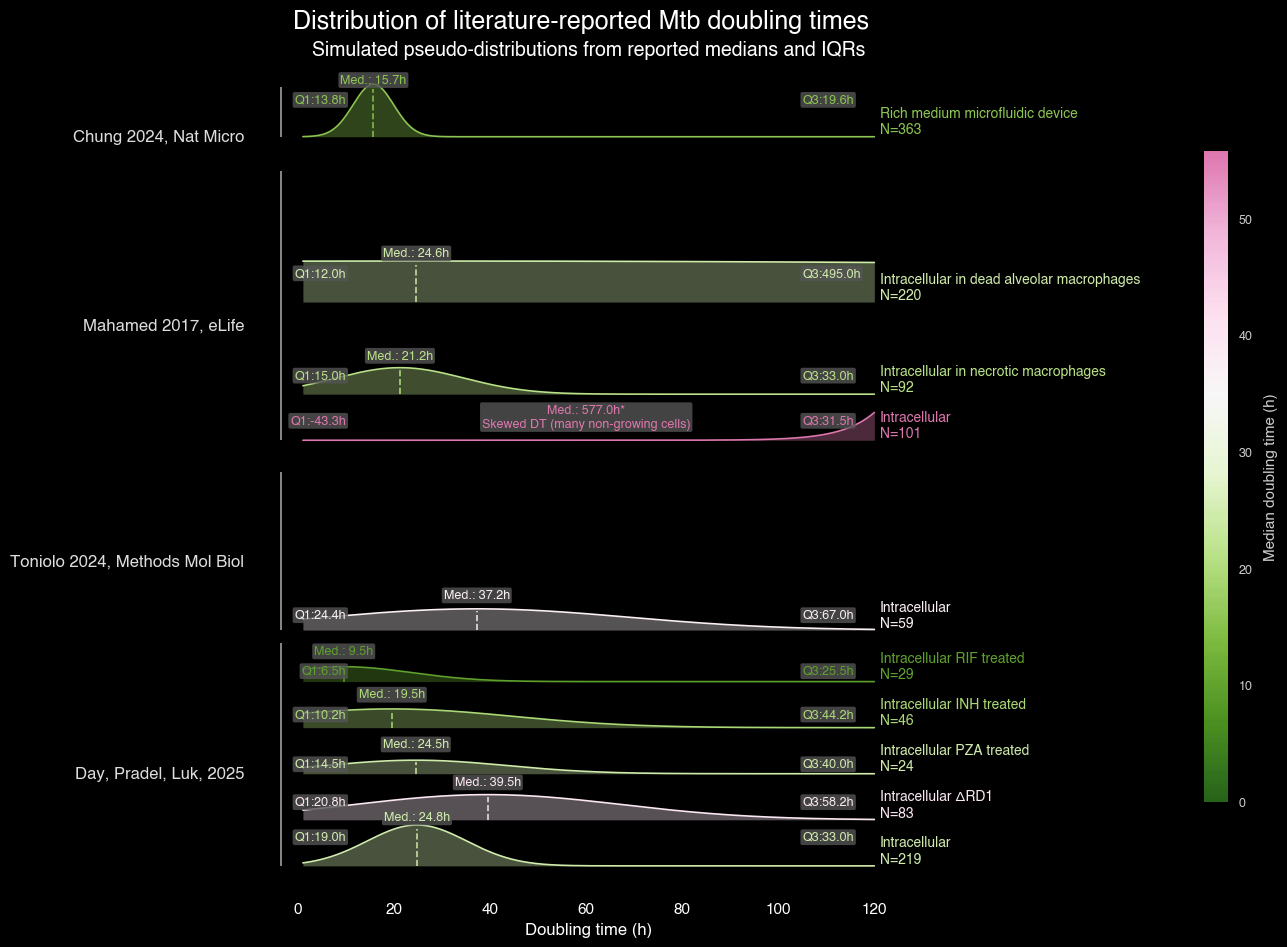

In [228]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import pandas as pd

# 1. Set Dark Mode
plt.style.use('dark_background')

# 2. Create the Custom Cropped Colormap (PiYG)
# We crop it to remove the darkest end if necessary, or just to limit the range.
# Based on your snippet: 0.0 to 0.8
old_cmap = plt.cm.get_cmap('PiYG_r')
start = 0.0 
stop  = 0.8 
new_colors = old_cmap(np.linspace(start, stop, 256))
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", new_colors)

# Standard Keynote/PowerPoint Widescreen ratio is 16:9
aspect_ratio = 12 / 9

# Set a fixed width (13 inches is usually good for slides with standard font sizes)
fig_width = 13 
fig_height = fig_width / aspect_ratio

# Create the figure with these fixed dimensions
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# 4. Main Plotting Loop
for (idv, cult), d in plot_df.groupby(["ID", "Culture details"], sort=False):
    base  = base_for[(idv, cult)]
    ypeak = d["y"].max() * height_scale * gain
    yplot = base + d["y"] * height_scale * gain

    # --- COLOR SELECTION LOGIC (Fixed to remove Plasma) ---
    # Retrieve the median for this specific pair
    med_val_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "Median (h)"]
    
    # Calculate color dynamically using the NEW cmap and existing norm
    if not med_val_series.empty and pd.notna(med_val_series.values[0]):
        median_val = med_val_series.values[0]
        col = cmap(norm(median_val)) # Uses the new PiYG map
    else:
        # Fallback: Use the end of the colormap (lightest/brightest part) 
        # instead of gray, so it is visible on black.
        col = cmap(1.0) 

    # Plot Distribution
    ax.fill_between(d["x"], base, yplot, color=col, alpha=0.35, linewidth=0)
    ax.plot(d["x"], yplot, color=col, lw=1.2)

    # Plot Dashed Median Line
    if not med_val_series.empty and med_val_series.values[0] > 0:
        ax.vlines(med_val_series.values[0], base, base + 0.9 * ypeak,
                  colors=col, linestyles="--", lw=1.2, alpha=0.9)

    # Inline N label
    N_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "N"]
    N_text = f"N={int(N_series.values[0])}" if (not N_series.empty and pd.notna(N_series.values[0])) else "N=NA"
    
    # Text styling based on culture type
    if 'IFN' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontstyle='italic')
    elif 'treated' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontweight='bold')    
    else:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col)

    # Quartile Tags
    row = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult),
                 ["Q1 (h)", "Median (h)", "Q3 (h)"]]
    if not row.empty:
        q1, medx, q3 = row.iloc[0]["Q1 (h)"], row.iloc[0]["Median (h)"], row.iloc[0]["Q3 (h)"]
        y_anchor = base + 0.7 * ypeak
        x_left, x_right = 10, 105

        # Box style for dark mode: Light grey background (#E0E0E0)
        bbox_style = dict(boxstyle="round,pad=0.15", fc="#555555", ec="none", alpha=0.8)

        if pd.notna(q1):
            ax.text(x_left, y_anchor, f"Q1:{q1:.1f}h",
                    ha="right", va="center", fontsize=9, color=col,
                    bbox=bbox_style, zorder=5)

        if pd.notna(medx):
            if xmin <= medx <= xmax:
                ax.text(medx, y_anchor + 15, f"Med.: {medx:.1f}h",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=bbox_style, zorder=5)
            else:
                ax.text(xmax/2, y_anchor - 10, f"Med.: {medx:.1f}h*\nSkewed DT (many non-growing cells)",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=bbox_style, zorder=5)

        if pd.notna(q3):
            ax.text(x_right, y_anchor, f"Q3:{q3:.1f}h",
                    ha="left", va="center", fontsize=9, color=col,
                    bbox=bbox_style, zorder=5)

# 5. Vertical Group Lines
span = {}
for idv in ids_order:
    bases = [base_for[(idv, c)] for c in id_specs[idv]["cults"]]
    y_low = min(bases)
    ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
    y_high = max(bases) + 0.95 * ypeak_max
    span[idv] = (y_low, y_high)

xpad  = 0.03 * (xmax - xmin)
xline = xmin - xpad
for idv in ids_order:
    y0, y1 = span[idv]
    # Divider lines: Light grey for visibility
    ax.vlines(xline, y0, y1, colors="#aaaaaa", linestyles="-", lw=1.4, alpha=0.8)

# 6. Axes + Labels
ax.set_xlim(xmin - 2 * xpad, xmax * 1.07)
y_allmin = min(v[0] for v in span.values())
y_allmax = max(v[1] for v in span.values())
ypad = 0.03 * (y_allmax - y_allmin)
ax.set_ylim(y_allmin - ypad, y_allmax + ypad)
ax.margins(y=0)
ax.set_yticks([]); ax.set_ylabel("")
plt.subplots_adjust(left=0.32, right=0.92)

# ID Labels on left
from matplotlib.transforms import blended_transform_factory
bt = blended_transform_factory(ax.transAxes, ax.transData)
for idv in ids_order:
    # Text: Very light grey (#ddd)
    ax.text(-0.03, y_center[idv], idv, transform=bt,
            ha="right", va="center", fontsize=12, color="#ddd", clip_on=False)

ax.set_xlabel("Doubling time (h)")
sns.despine(left=True, bottom=True, offset=10)

# Titles
fig.suptitle("Distribution of literature-reported Mtb doubling times",
             fontsize=18, fontweight="bold", y=0.97, color='white', x=0.45)
ax.set_title("Simulated pseudo-distributions from reported medians and IQRs",
             fontsize=14, fontweight="normal", color='white')

# 7. Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax,
                    orientation='vertical',
                    fraction=0.025,
                    pad=0.3,
                    aspect=27,
                    shrink=1,
                    anchor=(2.5, 0.5))

# Colorbar aesthetics for Dark Mode
cbar.outline.set_visible(False)
cbar.ax.tick_params(width=0, length=4, labelsize=9, colors='0.8') # Light ticks
cbar.set_label("Median doubling time (h)", fontsize=11, color='0.8', labelpad=8)
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()

plt.tight_layout()
# Save with facecolor included to ensure black background persists
# plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/psuedo_dist_w_atbs_dark_for_slides.pdf', 
#             bbox_inches='tight', dpi=314, facecolor=fig.get_facecolor())
plt.show()

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_27051/2354280395.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG_r')


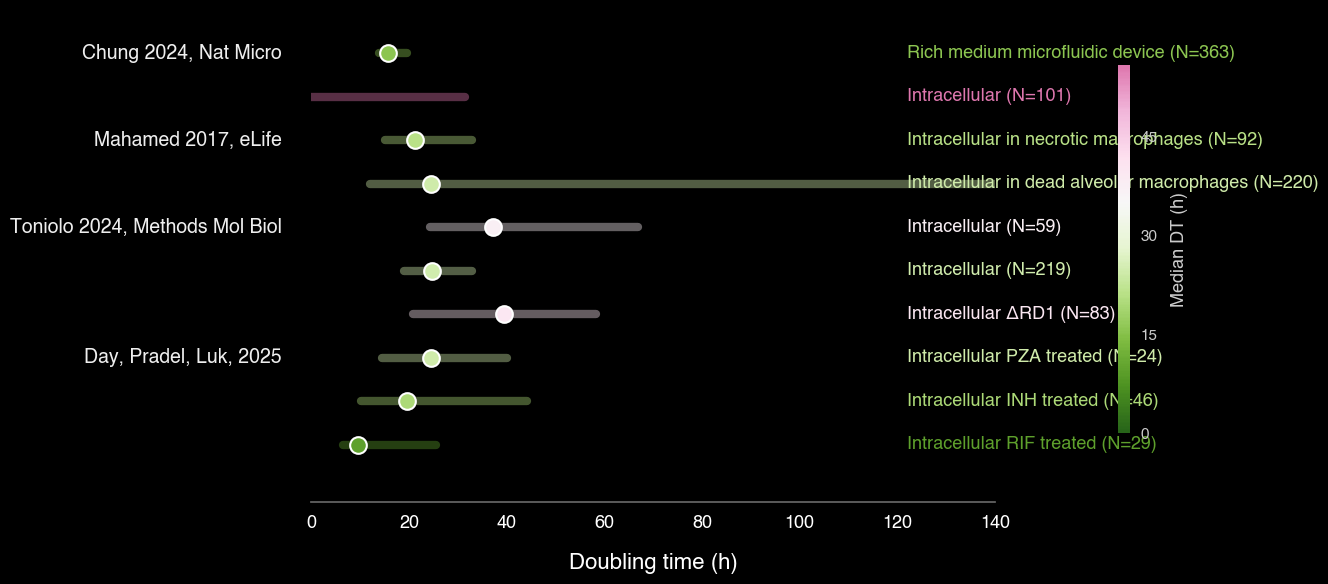

In [229]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import numpy as np
import seaborn as sns
import pandas as pd

# 1. Setup & Colormap
plt.style.use('dark_background')
old_cmap = plt.cm.get_cmap('PiYG_r')
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", old_cmap(np.linspace(0.0, 0.8, 256)))

# Ensure Data is Sorted by ID so groups are contiguous
# This is crucial for the vertical lines to look correct
# df = df.sort_values(by=['ID', 'Culture details'], ascending=[True, True])

# 2. Dimensions
n_rows = len(df)
fig_width = 13
fig_height = max(4, n_rows * 0.6) 
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Reverse y-positions so the first row in df is at the top
y_positions = np.arange(n_rows)[::-1]

# 3. Main Plotting Loop (Data Only)
for i, (idx, row) in enumerate(df.iterrows()):
    y_pos = y_positions[i]
    med = row["Median (h)"]
    q1, q3 = row["Q1 (h)"], row["Q3 (h)"]
    cult = row["Culture details"]
    
    col = cmap(norm(med)) if pd.notna(med) else cmap(1.0)

    # IQR Range Line
    ax.hlines(y_pos, q1, q3, colors=col, lw=6, alpha=0.4, capstyle='round')
    
    # Median Point
    ax.plot(med, y_pos, marker='o', markersize=12, color=col, 
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)

    # Condition Label (Right Side)
    N_text = f"N={int(row['N'])}" if pd.notna(row['N']) else "N=NA"
    style = {'fontstyle': 'italic'} if 'IFN' in cult else {'fontweight': 'bold'} if 'treated' in cult else {}
    
    # Standardised xmax placement for tidiness
    ax.text(xmax + 2, y_pos, f"{cult} ({N_text})", 
            ha="left", va="center", fontsize=13, color=col, **style)

# 4. Vertical Grouping Lines (Author IDs on Left)
# We determine the left-offset based on xmin
x_line_pos = xmin - 5  # Vertical line position
x_text_pos = x_line_pos - 1 # Text position

# Iterate through groups to calculate spans
# We use integer indexing to map df rows to y_positions
current_row_idx = 0

for idv, group in df.groupby("ID", sort=False):
    num_entries = len(group)
    
    # Get the specific Y-positions for this group
    # Because df is sorted, these are contiguous slices of our y_positions array
    group_y_indices = range(current_row_idx, current_row_idx + num_entries)
    group_y_pos = [y_positions[i] for i in group_y_indices]
    
    y_top = max(group_y_pos)
    y_bottom = min(group_y_pos)
    y_center = (y_top + y_bottom) / 2
    
    # Draw Vertical Group Line (Light Grey)
    # If it's a single entry, we draw a small line to indicate the row
    if num_entries == 1:
        ax.vlines(x_line_pos, y_bottom - 0.2, y_top + 0.2, colors="#aaaaaa", lw=1.5)
    else:
        ax.vlines(x_line_pos, y_bottom, y_top, colors="#aaaaaa", lw=1.5)

    # Draw Author Name Centered
    ax.text(x_text_pos, y_center, idv, 
            ha="right", va="center", fontsize=14, color="#eeeeee")
    
    # Advance counter
    current_row_idx += num_entries

# 5. Axes Polish
ax.set_yticks([])
ax.set_ylim(-1, n_rows)
ax.set_xlim(xmin - 25, xmax + 5) # Increased left padding to fit Author Names
ax.set_xlabel("Doubling time (h)", color='white', fontsize=16, labelpad=15)
ax.tick_params(axis='x', labelsize=13, colors='white')

sns.despine(left=True, bottom=False, offset=10)
ax.spines['bottom'].set_color('#666666')

# 6. Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.015, pad=0.15, aspect=30)
cbar.outline.set_visible(False)
cbar.ax.tick_params(width=0, length=4, labelsize=11, colors='0.8')
cbar.set_label("Median DT (h)", fontsize=13, color='0.8', labelpad=10)
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()
plt.xlim(0, 140)
plt.tight_layout()
plt.show()

In [230]:
# Replace 2025 with an empty string
# Remove ", 2025" from the ID column
df['ID'] = df['ID'].str.replace(', 2025', '', regex=False)

In [231]:
df['ID'] = df['ID'].str.replace(', 2025', '', regex=False)

In [232]:
df

,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,NaN,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
3,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
4,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
5,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular,Intrinsic,Yes,...,219,4.00,68.00,,,,,,,"Day, Pradel, Luk"
6,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,ΔRD1,Intracellular ΔRD1,Intrinsic,Yes,...,83,7.00,68.00,,,,,,,"Day, Pradel, Luk"
7,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular PZA treated,Intrinsic,Yes,...,24,4.00,73.50,,,,,,,"Day, Pradel, Luk"
8,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular INH treated,Intrinsic,Yes,...,46,1.50,67.00,,,,,,,"Day, Pradel, Luk"
9,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular RIF treated,Intrinsic,Yes,...,29,3.00,48.00,,,,,,,"Day, Pradel, Luk"


In [233]:
df.iloc[3]['Q1 (h)']

np.float64(12.0)

In [234]:
df.iloc[3]['Q3 (h)']

np.float64(495.0)

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_27051/3923841620.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG_r')


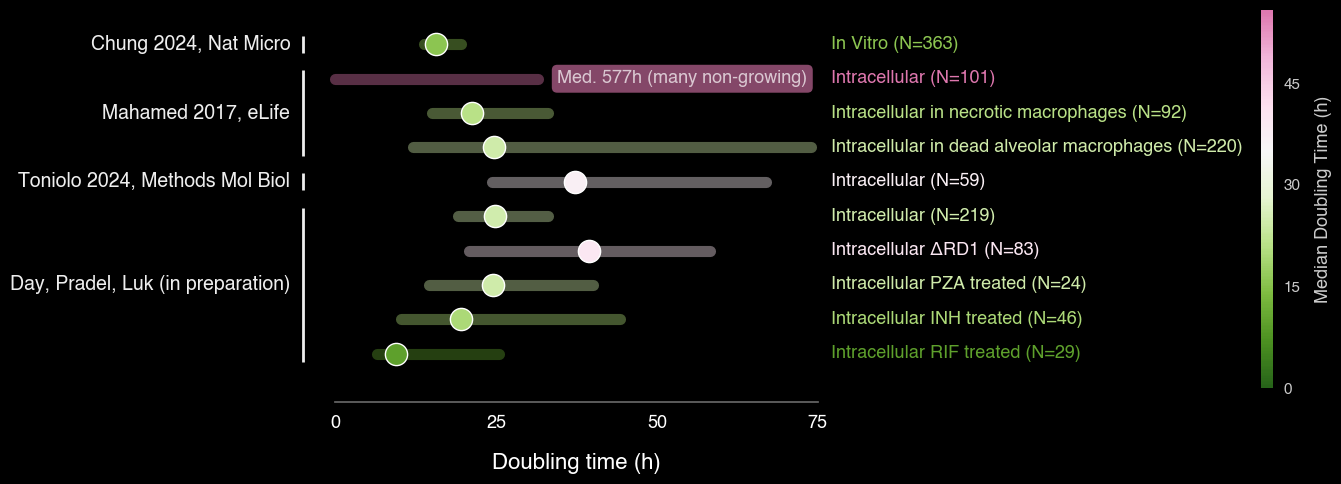

In [235]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import numpy as np
import seaborn as sns
import pandas as pd
from itertools import groupby

# 1. Setup & Colormap
plt.style.use('dark_background')
old_cmap = plt.cm.get_cmap('PiYG_r')
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", old_cmap(np.linspace(0.0, 0.8, 256)))

# --- STRING MANIPULATION ---
# 1. Remove ", 2025" from the ID column (as requested previously)
df['ID'] = df['ID'].str.replace(', 2025', '', regex=False)

# 2. Append "(in preparation)" specifically to the Day et al. rows
# We use .loc to target rows containing "Day" and modify the ID
mask_day = df['ID'].str.contains("Day")
df.loc[mask_day, 'ID'] = df.loc[mask_day, 'ID'] + " (in preparation)"

# 2. Dimensions & Spacing
n_rows = len(df)
fig_width = 14  
fig_height = max(5, n_rows * 0.5) 
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

y_positions = np.arange(n_rows)[::-1]

# 3. Main Plotting Loop (Data Only)
for i, (idx, row) in enumerate(df.iterrows()):
    y_pos = y_positions[i]
    med = row["Median (h)"]
    q1, q3 = row["Q1 (h)"], row["Q3 (h)"]

    # Manual overrides
    if i == 1:
        q1 = 0 
        q3 = 31.5
        # med = 90
    if i == 3:
        q1 = 12
        q3 = 74
        # med = 0 

    cult = row["Culture details"]
    if 'Rich' in cult:
        cult = 'In Vitro'

    # --- STYLE LOGIC ---
    if 'IFN' in cult:
        style = {'fontstyle': 'italic'}
    elif 'treated' in cult:
        style = {'fontweight': 'bold'}
    else:
        style = {}
    
    # Bold the final 5 rows (The Day et al rows)
    if i >= n_rows - 5:
        style['fontweight'] = 'bold'

    col = cmap(norm(med)) if pd.notna(med) else cmap(1.0)
    
    # --- Text with Alpha ---
    if i == 1:
        # Text color is (1, 1, 1, 0.7) for transparency
        ax.text(34.5, y_pos, f"Med. 577h (many non-growing)", 
                ha="left", va="center", fontsize=13, 
                color=(1, 1, 1, 0.7), 
                bbox=dict(boxstyle="round,pad=0.3", fc=col, ec="none", alpha=0.6), **style)

    # IQR Range Line
    ax.hlines(y_pos, q1, q3, colors=col, lw=8, alpha=0.4, capstyle='round')
    
    # Median Point
    ax.plot(med, y_pos, marker='o', markersize=16, color=col, 
            markeredgecolor='white', markeredgewidth=1, zorder=5)

    # Condition Label
    N_text = f"N={int(row['N'])}" if pd.notna(row['N']) else "N=NA"
    ax.text(77, y_pos, f"{cult} ({N_text})", 
            ha="left", va="center", fontsize=13, color=col, **style)

# 4. Vertical Grouping Lines
x_line_pos = -5   
x_text_pos = -7   
row_pointer = 0 
v_pad = 0.25 

for idv, group_iter in groupby(df["ID"]):
    group_rows = list(group_iter)
    num_entries = len(group_rows)
    
    y_span_indices = range(row_pointer, row_pointer + num_entries)
    current_y_positions = [y_positions[i] for i in y_span_indices]
    
    y_top = max(current_y_positions)
    y_bottom = min(current_y_positions)
    y_center = (y_top + y_bottom) / 2
    
    ax.vlines(x_line_pos, y_bottom - v_pad, y_top + v_pad, colors="#eeeeee", lw=2)
    ax.text(x_text_pos, y_center, idv, 
            ha="right", va="center", fontsize=14, color="#eeeeee", fontweight='bold')
    
    row_pointer += num_entries

# 5. Axes Polish
ax.set_yticks([])
ax.set_ylim(-1, n_rows)

# Clip the view
# Note: x_min is -50, x_max is 75. Total width = 125.
x_min, x_max = -50, 75
ax.set_xlim(x_min, x_max) 

# Ticks stop at 75
ax.set_xticks(np.arange(0, 76, 25))

# --- CENTER LABEL AT X=37.5 ---
target_x = 37.5
x_pos_norm = (target_x - x_min) / (x_max - x_min)

ax.set_xlabel("Doubling time (h)", color='white', fontsize=16, labelpad=15, 
              x=x_pos_norm, ha='center')

ax.tick_params(axis='x', labelsize=13, colors='white')

sns.despine(left=True, bottom=False, offset=10)

ax.spines['bottom'].set_bounds(0, 75)
ax.spines['bottom'].set_color('#666666')

# 6. Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.015, pad=0.35, aspect=30)
cbar.outline.set_visible(False)
cbar.ax.tick_params(width=0, length=4, labelsize=11, colors='0.8')
cbar.set_label("Median Doubling Time (h)", fontsize=13, color='0.8', labelpad=10)
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/acid_fast_pres_dist_allv2.pdf', 
            bbox_inches='tight', dpi=314, facecolor=fig.get_facecolor())
plt.show()

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_27051/572032749.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG_r')


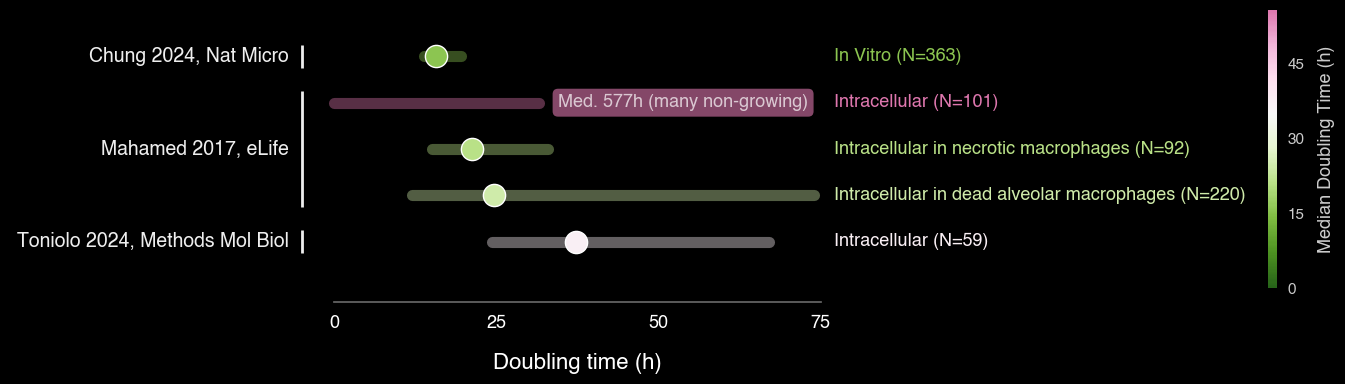

In [236]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import numpy as np
import seaborn as sns
import pandas as pd
from itertools import groupby

# 1. Setup & Colormap
plt.style.use('dark_background')
old_cmap = plt.cm.get_cmap('PiYG_r')
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", old_cmap(np.linspace(0.0, 0.8, 256)))

# --- CHANGED: Remove the last 5 rows from the dataframe ---
df = df.iloc[:-5].copy() 

# 2. Dimensions & Spacing
n_rows = len(df)
fig_width = 14  
fig_height = max(4, n_rows * 0.6) # Slightly adjusted height ratio for fewer rows
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

y_positions = np.arange(n_rows)[::-1]

# 3. Main Plotting Loop (Data Only)
for i, (idx, row) in enumerate(df.iterrows()):
    y_pos = y_positions[i]
    med = row["Median (h)"]
    q1, q3 = row["Q1 (h)"], row["Q3 (h)"]

    # Manual overrides (Indices 0-3 are preserved at the top)
    if i == 1:
        q1 = 0 
        q3 = 31.5
    if i == 3:
        q1 = 12
        q3 = 74

    cult = row["Culture details"]
    if 'Rich' in cult:
        cult = 'In Vitro'

    # --- STYLE LOGIC ---
    if 'IFN' in cult:
        style = {'fontstyle': 'italic'}
    elif 'treated' in cult:
        style = {'fontweight': 'bold'}
    else:
        style = {}
    
    # Removed the "Bold final 5 rows" block since those rows are deleted.

    col = cmap(norm(med)) if pd.notna(med) else cmap(1.0)
    
    # --- Text with Alpha ---
    if i == 1:
        ax.text(34.5, y_pos, f"Med. 577h (many non-growing)", 
                ha="left", va="center", fontsize=13, 
                color=(1, 1, 1, 0.7), 
                bbox=dict(boxstyle="round,pad=0.3", fc=col, ec="none", alpha=0.6), **style)

    # IQR Range Line
    ax.hlines(y_pos, q1, q3, colors=col, lw=8, alpha=0.4, capstyle='round')
    
    # Median Point
    ax.plot(med, y_pos, marker='o', markersize=16, color=col, 
            markeredgecolor='white', markeredgewidth=1, zorder=5)

    # Condition Label
    N_text = f"N={int(row['N'])}" if pd.notna(row['N']) else "N=NA"
    ax.text(77, y_pos, f"{cult} ({N_text})", 
            ha="left", va="center", fontsize=13, color=col, **style)

# 4. Vertical Grouping Lines
x_line_pos = -5   
x_text_pos = -7   
row_pointer = 0 
v_pad = 0.25 

for idv, group_iter in groupby(df["ID"]):
    group_rows = list(group_iter)
    num_entries = len(group_rows)
    
    y_span_indices = range(row_pointer, row_pointer + num_entries)
    current_y_positions = [y_positions[i] for i in y_span_indices]
    
    y_top = max(current_y_positions)
    y_bottom = min(current_y_positions)
    y_center = (y_top + y_bottom) / 2
    
    ax.vlines(x_line_pos, y_bottom - v_pad, y_top + v_pad, colors="#eeeeee", lw=2)
    ax.text(x_text_pos, y_center, idv, 
            ha="right", va="center", fontsize=14, color="#eeeeee", fontweight='bold')
    
    row_pointer += num_entries

# 5. Axes Polish
ax.set_yticks([])
ax.set_ylim(-1, n_rows)

# Clip the view
x_min, x_max = -50, 75
ax.set_xlim(x_min, x_max) 

# Ticks stop at 75
ax.set_xticks(np.arange(0, 76, 25))

# --- CENTER LABEL AT X=37.5 ---
target_x = 37.5
x_pos_norm = (target_x - x_min) / (x_max - x_min)

ax.set_xlabel("Doubling time (h)", color='white', fontsize=16, labelpad=15, 
              x=x_pos_norm, ha='center')

ax.tick_params(axis='x', labelsize=13, colors='white')

sns.despine(left=True, bottom=False, offset=10)

ax.spines['bottom'].set_bounds(0, 75)
ax.spines['bottom'].set_color('#666666')

# 6. Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.015, pad=0.35, aspect=30)
cbar.outline.set_visible(False)
cbar.ax.tick_params(width=0, length=4, labelsize=11, colors='0.8')
cbar.set_label("Median Doubling Time (h)", fontsize=13, color='0.8', labelpad=10)
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/acid_fast_pres_dist_truncated.pdf', 
            bbox_inches='tight', dpi=314, facecolor=fig.get_facecolor())
plt.show()